
image 1/1 /content/bricks.jpg: 448x640 (no detections), 454.6ms
Speed: 20.8ms preprocess, 454.6ms inference, 27.8ms postprocess per image at shape (1, 3, 448, 640)


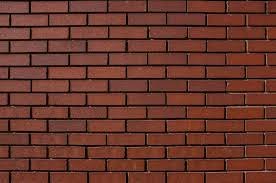

In [2]:
!pip install ultralytics

from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

model = YOLO("yolov8n.pt")

results = model("/content/bricks.jpg", conf=0.5)

for result in results:
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        cls_id = int(box.cls[0].item())
        cls_name = model.names[cls_id]
        print(f"{cls_name}: {conf:.2f} at [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]")

annotated = results[0].plot()
cv2_imshow(annotated)